<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

## **Proyecto K-vecinos más Cercanos**

**Autora:** Anais Aponte  
**Bootcamp:** 4Geeks Academy – Intro to Machine Learning  
**Proyecto:** Proyecto K-vecinos más Cercanos  

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### 📝 **Instrucciones**

#### **Clasificador de Vinos con KNN**

El objetivo es entrena un modelo de K-Vecinos más Cercanos (KNN) para predecir la calidad de un vino tinto a partir de sus características químicas.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### 📝 **Paso 1: Carga del conjunto de datos**

El dataset utilizado en este proyecto es **winequality-red.csv**.

Para facilitar la reproducibilidad y evitar dependencias externas, el archivo ha sido previamente descargado y almacenado dentro del repositorio en la siguiente ruta:

📁 `data/raw/winequality-red.csv`

De esta forma, el notebook puede ejecutarse directamente sin necesidad de acceder a enlaces externos.

A continuación se realizan primero las importaciones necesarias y, posteriormente, la carga del dataset para iniciar el análisis.

</div>

In [20]:
# Manipulación de datos
import pandas as pd
# Preprocesamiento
from sklearn.preprocessing import StandardScaler
# División de datos
from sklearn.model_selection import train_test_split
# Modelos
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
# Métricas
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
# Graficos
import seaborn as sns
import matplotlib.pyplot as plt
# Importamos la librería para guardar modelos
import joblib





In [3]:
# CARGAMOS EL FICHERO CON LOS DATOS A ANALIZAR
df = pd.read_csv('../data/raw/winequality-red.csv', sep=';')

# Visualizamos 10 registros aleatorios del dataset con sample(). Esto nos permite observar una muestra representativa de los datos,
# ya que algunos datasets pueden estar ordenados (por fecha, id, etc.).
df.sample(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1174,7.6,0.360,0.31,1.7,0.079,26.0,65.0,0.99716,3.46,0.62,9.5,6
1328,6.5,0.520,0.11,1.8,0.073,13.0,38.0,0.99550,3.34,0.52,9.3,5
503,10.5,0.260,0.47,1.9,0.078,6.0,24.0,0.99760,3.18,1.04,10.9,7
1353,7.6,0.645,0.03,1.9,0.086,14.0,57.0,0.99690,3.37,0.46,10.3,5
1583,6.2,0.460,0.29,2.1,0.074,32.0,98.0,0.99578,3.33,0.62,9.8,5
619,11.3,0.370,0.41,2.3,0.088,6.0,16.0,0.99880,3.09,0.80,9.3,5
567,8.7,0.700,0.24,2.5,0.226,5.0,15.0,0.99910,3.32,0.60,9.0,6
832,10.4,0.440,0.42,1.5,0.145,34.0,48.0,0.99832,3.38,0.86,9.9,3
799,9.4,0.500,0.34,3.6,0.082,5.0,14.0,0.99870,3.29,0.52,10.7,6


<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación inicial**

En este dataset se identifican 12 variables que representan la composicion quimica de cada vino siendo cada fila un vino.

</div>

<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">

A continuación se detallan las variables incluidas en el dataset:

### 📊 Diccionario de Datos

- fixed acidity, volatile acidity, citric acid

- residual sugar, chlorides

- free sulfur dioxide, total sulfur dioxide

- density, pH, sulphates, alcohol

</div>

------

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 1.1: Inpección y preparación inicial del dataset**

</div>

In [4]:
# Obtener las dimensiones
df.shape

(1599, 12)

In [5]:
# Obtener información sobre tipos de datos y valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [6]:
# ¿Cuantos valores diferentes hay en la variable quality?
df['quality'].unique()

array([5, 6, 7, 4, 8, 3])

In [7]:
# ¿Que proporcion hay de esos valores en el dataset?
df['quality'].value_counts().sort_index()

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación sobre la estructura del dataset**

El dataset está compuesto por 12 variables (todas numericas) y 1599 observaciones, y no se identifican valores nulos en ninguna de las variables.

La columna `quality` representa una escala ordinal de la calidad del vino, donde valores más altos indican mejor calidad. En este dataset, los valores observados van de 3 a 8.

Dado que la columna objetivo requerida es `label` y no existe actualmente en el dataset, se procederá a crearla a partir de la variable `quality`.

Además, dado que `quality` presenta múltiples valores, se transforma en una variable categórica (`label`) para abordar el problema como una tarea de clasificación.

Por lo tanto, se define la siguiente conversión:

- Baja calidad → valores 3 y 4 → 0  
- Calidad media → valores 5 y 6 → 1  
- Alta calidad → valores 7 y 8 → 2 


</div>

In [8]:
# Creamos la columna 'label' a partir de 'quality' agrupando los valores en baja (0), media (1) y alta (2)
df['label'] = df['quality'].map({
    3: 0, 4: 0,
    5: 1, 6: 1,
    7: 2, 8: 2
})

In [9]:
# Verificamos la distribución de la nueva variable 'label'
df['label'].value_counts().sort_index()

label
0      63
1    1319
2     217
Name: count, dtype: int64

In [10]:
# Observamos en nuevo dataframe con la nueva variable objetivo (label)
df.sample(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,label
551,9.4,0.430,0.24,2.8,0.092,14.0,45.0,0.99800,3.19,0.73,10.0,6,1
1308,9.7,0.690,0.32,2.5,0.088,22.0,91.0,0.99790,3.29,0.62,10.1,5,1
137,7.2,0.415,0.36,2.0,0.081,13.0,45.0,0.99720,3.48,0.64,9.2,5,1
934,6.6,0.610,0.01,1.9,0.080,8.0,25.0,0.99746,3.69,0.73,10.5,5,1
147,7.6,0.490,0.26,1.6,0.236,10.0,88.0,0.99680,3.11,0.80,9.3,5,1
777,6.9,0.635,0.17,2.4,0.241,6.0,18.0,0.99610,3.40,0.59,10.3,6,1
1534,6.6,0.560,0.14,2.4,0.064,13.0,29.0,0.99397,3.42,0.62,11.7,7,2
1585,7.2,0.390,0.44,2.6,0.066,22.0,48.0,0.99494,3.30,0.84,11.5,6,1
1089,11.6,0.410,0.54,1.5,0.095,22.0,41.0,0.99735,3.02,0.76,9.9,7,2
1342,7.6,0.540,0.02,1.7,0.085,17.0,31.0,0.99589,3.37,0.51,10.4,6,1


In [11]:
# Se elimina de dataframe la variable 'quality' que no debe estar porque contiene información directa del target
df = df.drop(columns='quality')
df.sample(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,label
861,5.8,1.01,0.66,2.0,0.039,15.0,88.0,0.99357,3.66,0.60,11.5,1
311,7.9,0.53,0.24,2.0,0.072,15.0,105.0,0.99600,3.27,0.54,9.4,1
1030,7.1,0.59,0.00,2.1,0.091,9.0,14.0,0.99488,3.42,0.55,11.5,2
496,7.8,0.52,0.25,1.9,0.081,14.0,38.0,0.99840,3.43,0.65,9.0,1
1463,6.9,0.63,0.01,2.4,0.076,14.0,39.0,0.99522,3.34,0.53,10.8,1
1101,7.4,0.49,0.27,2.1,0.071,14.0,25.0,0.99388,3.35,0.63,12.0,1
1402,7.6,0.30,0.42,2.0,0.052,6.0,24.0,0.99630,3.44,0.82,11.9,1
1477,5.3,0.47,0.11,2.2,0.048,16.0,89.0,0.99182,3.54,0.88,13.6,2
1519,6.6,0.70,0.08,2.6,0.106,14.0,27.0,0.99665,3.44,0.58,10.2,1
931,7.4,0.61,0.01,2.0,0.074,13.0,38.0,0.99748,3.48,0.65,9.8,1


------

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2: Entrena el modelo KNN**

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

#### **Paso 2.1: Separar X y y**

</div>

In [12]:
# Separamos variables predictoras (X) y variable objetivo (y)
X = df.drop(columns='label')
y = df['label']

X.sample(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
794,10.1,0.270,0.54,2.3,0.065,7.0,26.0,0.99531,3.17,0.53,12.5
500,7.8,0.520,0.25,1.9,0.081,14.0,38.0,0.99840,3.43,0.65,9.0
1410,6.6,0.960,0.00,1.8,0.082,5.0,16.0,0.99360,3.50,0.44,11.9
677,8.6,0.800,0.11,2.3,0.084,12.0,31.0,0.99790,3.40,0.48,9.9
1106,8.2,0.230,0.42,1.9,0.069,9.0,17.0,0.99376,3.21,0.54,12.3
638,7.7,0.915,0.12,2.2,0.143,7.0,23.0,0.99640,3.35,0.65,10.2
920,9.6,0.410,0.37,2.3,0.091,10.0,23.0,0.99786,3.24,0.56,10.5
946,10.2,0.440,0.58,4.1,0.092,11.0,24.0,0.99745,3.29,0.99,12.0
366,12.8,0.615,0.66,5.8,0.083,7.0,42.0,1.00220,3.07,0.73,10.0
1027,6.4,0.795,0.00,2.2,0.065,28.0,52.0,0.99378,3.49,0.52,11.6


<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

#### **Paso 2.2: Train / Test split (80/20)**

</div>

In [13]:
# Dividimos los datos en entrenamiento y test manteniendo (80/20) manteniendo la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
72,7.7,0.69,0.22,1.9,0.084,18.0,94.0,0.99610,3.31,0.48,9.5
1212,6.8,0.65,0.02,2.1,0.078,8.0,15.0,0.99498,3.35,0.62,10.4
1305,7.5,0.61,0.26,1.9,0.073,24.0,88.0,0.99612,3.30,0.53,9.8
315,7.1,0.35,0.29,2.5,0.096,20.0,53.0,0.99620,3.42,0.65,11.0
1061,9.1,0.40,0.50,1.8,0.071,7.0,16.0,0.99462,3.21,0.69,12.5


<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

#### **Paso 2.3: Escala los datos si es necesario (¡muy recomendable con KNN!)**

</div>

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

#### 💡 **Nota:**

Dado que KNN funciona con ditancias si no se escalara las variables con valores grandes dominarían y las que tiene valores pequeños no influirían. Por tanto se procede a escalar.

Y se escalará mediante la técnica de estandarización (StandardScaler), ya que es una práctica habitual en modelos basados en distancias como KNN.

</div>

In [14]:
# Inicializamos el scaler para estandarizar los datos (media 0, desviación estándar 1)
scaler = StandardScaler()

# Ajustamos el scaler solo con los datos de entrenamiento y transformamos train y test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

#### **Paso 2.4: Entrena el modelo con un valor de k inicial**

</div>

In [15]:
# Inicializamos el modelo con configuración por defecto, a saber
# n_neighbors = 5 → K inicial
# metric = 'minkowski'
# p = 2 → equivale a distancia euclidiana
# weights = 'uniform' → todos los vecinos pesan igual
model = KNeighborsClassifier()

# Entrenamos el modelo con los datos de entrenamiento
model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


------

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 3: Evalúa el rendimiento usando**

</div>

In [16]:
# Generamos las predicciones del modelo
y_pred = model.predict(X_test_scaled)

In [17]:
# Calculamos la precisión global del modelo comparando las predicciones con los valores reales
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8187


In [18]:
# Generamos la matriz de confusión para ver cómo se distribuyen los aciertos y errores por clase
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[  0  13   0]
 [  1 243  20]
 [  0  24  19]]


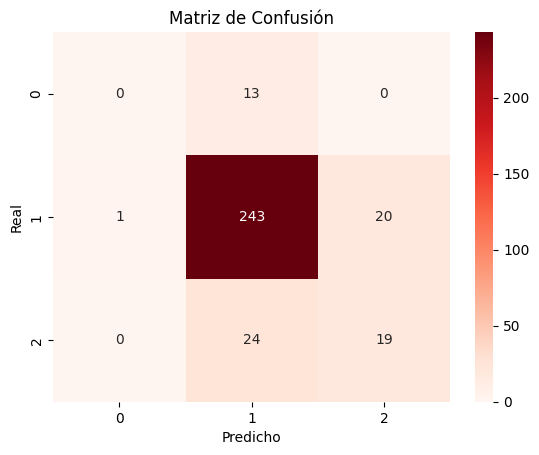

In [27]:
# Visualizamos la matriz de confusión de forma gráfica para facilitar su interpretación
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

In [19]:
# Mostramos el reporte de clasificación con precision, recall y f1-score por cada clase
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.87      0.92      0.89       264
           2       0.49      0.44      0.46        43

    accuracy                           0.82       320
   macro avg       0.45      0.45      0.45       320
weighted avg       0.78      0.82      0.80       320



<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación sobre el rendimiento del modelo**

El modelo KNN obtiene una precisión global aceptable (~0.82), mostrando un buen rendimiento en la clasificación de la clase mayoritaria (calidad media) y un desempeño moderado en la clase de alta calidad.

Sin embargo, no logra identificar correctamente ningún caso de baja calidad (clase 0), clasificándolos todos como calidad media. Este comportamiento se debe probablemente al desbalance en la distribución de las clases, donde la clase media está sobrerrepresentada, lo que provoca que el modelo tienda a predecir esta categoría.

Esto evidencia una limitación del modelo en la detección de clases minoritarias.


</div>

------

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Optimización de k. Crea un bucle para probar diferentes valores de k (por ejemplo, de 1 a 20).**

</div>

In [28]:
# Probamos distintos valores de K y guardamos la precisión obtenida en cada caso para identificar el mejor valor
k_values = range(1, 21)
accuracy_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred_k = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_k)
    accuracy_scores.append(acc)

# Mostramos la precisión obtenida para cada valor de K
for k, acc in zip(k_values, accuracy_scores):
    print(f"K = {k}: Accuracy = {acc:.4f}")

K = 1: Accuracy = 0.8187
K = 2: Accuracy = 0.8156
K = 3: Accuracy = 0.8281
K = 4: Accuracy = 0.8281
K = 5: Accuracy = 0.8187
K = 6: Accuracy = 0.8438
K = 7: Accuracy = 0.8438
K = 8: Accuracy = 0.8313
K = 9: Accuracy = 0.8375
K = 10: Accuracy = 0.8469
K = 11: Accuracy = 0.8594
K = 12: Accuracy = 0.8594
K = 13: Accuracy = 0.8438
K = 14: Accuracy = 0.8438
K = 15: Accuracy = 0.8375
K = 16: Accuracy = 0.8375
K = 17: Accuracy = 0.8313
K = 18: Accuracy = 0.8438
K = 19: Accuracy = 0.8375
K = 20: Accuracy = 0.8406


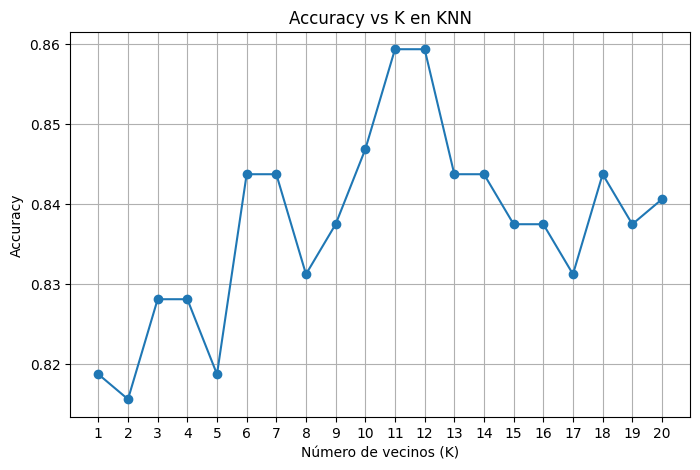

In [29]:
# Representamos gráficamente la relación entre el valor de K y la precisión del modelo
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracy_scores, marker='o')
plt.xlabel("Número de vecinos (K)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K en KNN")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [35]:
# Identificamos el valor de K que obtiene la mejor precisión en el conjunto de prueba
best_k = k_values[accuracy_scores.index(max(accuracy_scores))]
best_accuracy = max(accuracy_scores)

print(f"Mejor K: {best_k}")
print(f"Mejor Accuracy: {best_accuracy:.4f}")

Mejor K: 11
Mejor Accuracy: 0.8594


------

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **¿Te sientes confiada?**
Resp: Si

</div>

In [32]:
# Definimos una función que recibe las características de un vino y devuelve su calidad predicha
def predict_wine_quality(features):
    
    # Convertimos la entrada en un array 2D (formato requerido por sklearn)
    import numpy as np
    features_array = np.array(features).reshape(1, -1)
    
    # Aplicamos el mismo escalado que se utilizó en el entrenamiento
    features_scaled = scaler.transform(features_array)
    
    # Realizamos la predicción con el modelo entrenado
    prediction = model.predict(features_scaled)[0]
    
    # Traducimos la predicción numérica a una etiqueta comprensible
    if prediction == 0:
        return "Este vino probablemente sea de baja calidad 🍷"
    elif prediction == 1:
        return "Este vino probablemente sea de calidad media 🍷"
    else:
        return "Este vino probablemente sea de alta calidad 🍷"

In [33]:
# probamos llamando la funcion
predict_wine_quality([7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4])

/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


'Este vino probablemente sea de calidad media 🍷'